In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

## 1. Génération des données fictives

In [2]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    "jour_semaine": np.random.randint(0, 7, n),       # 0=lundi ... 6=dimanche
    "mois": np.random.randint(1, 13, n),               # 1-12
    "est_vacances": np.random.randint(0, 2, n),        # 0 ou 1
    "temperature_c": np.random.uniform(2, 22, n),      # Écosse : 2-22°C
    "est_pluvieux": np.random.randint(0, 2, n),        # 0 ou 1
})

# Formule fictive pour le nombre de visiteurs
df["visiteurs"] = (
    200
    + df["jour_semaine"].apply(lambda x: 150 if x >= 5 else 0)   # +150 le week-end
    + df["est_vacances"] * 300                                     # +300 en vacances
    + df["temperature_c"] * 5                                      # +5 par degré
    - df["est_pluvieux"] * 80                                      # -80 si pluie
    + df["mois"].apply(lambda x: 100 if x in [6,7,8] else 0)     # +100 été
    + np.random.normal(0, 30, n)                                   # bruit
).clip(50).astype(int)

df.head(10)

,jour_semaine,mois,est_vacances,temperature_c,est_pluvieux,visiteurs
0,6,6,1,6.439443,1,749
1,3,11,0,6.621496,0,223
2,4,12,0,15.437855,1,236
3,6,5,0,2.394211,0,325
4,2,1,0,4.082172,0,204
5,4,8,0,17.998322,0,347
6,4,5,1,5.570893,0,530
7,6,12,0,15.054922,1,368
8,1,12,0,6.763656,1,156
9,2,12,1,3.988828,0,556


## 2. Exploration rapide

       jour_semaine        mois  est_vacances  temperature_c  est_pluvieux  \
count    500.000000  500.000000      500.0000     500.000000    500.000000   
mean       2.954000    6.424000        0.4800      12.112457      0.496000   
std        2.027833    3.542502        0.5001       5.930548      0.500485   
min        0.000000    1.000000        0.0000       2.127717      0.000000   
25%        1.000000    3.000000        0.0000       6.731189      0.000000   
50%        3.000000    6.000000        0.0000      12.366293      0.000000   
75%        5.000000   10.000000        1.0000      17.349191      1.000000   
max        6.000000   12.000000        1.0000      21.958682      1.000000   

        visiteurs  
count  500.000000  
mean   428.504000  
std    183.343994  
min     87.000000  
25%    261.750000  
50%    433.500000  
75%    575.500000  
max    883.000000  


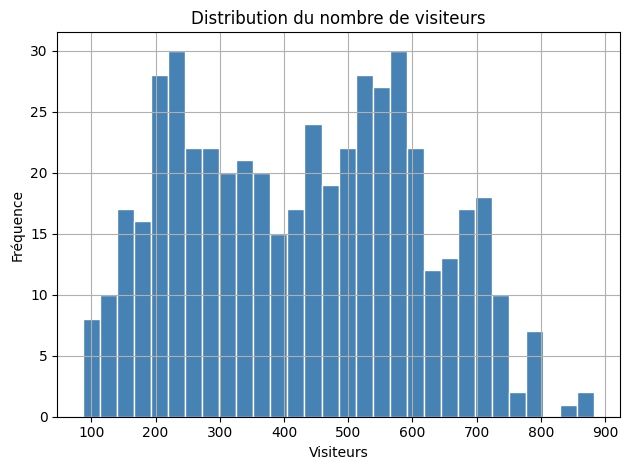

In [3]:
print(df.describe())
df["visiteurs"].hist(bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution du nombre de visiteurs")
plt.xlabel("Visiteurs")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

## 3. Entraînement du modèle

In [4]:
features = ["jour_semaine", "mois", "est_vacances", "temperature_c", "est_pluvieux"]
X = df[features]
y = df["visiteurs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE : {mae:.1f} visiteurs")

MAE : 36.7 visiteurs


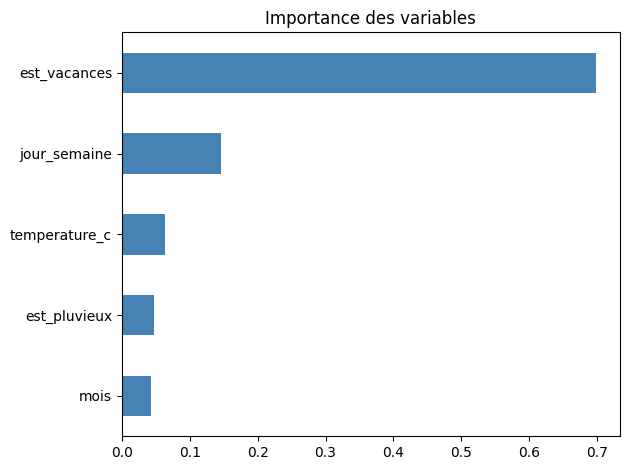

In [5]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", color="steelblue")
plt.title("Importance des variables")
plt.tight_layout()
plt.show()

## 4. Export du modèle

In [6]:
joblib.dump(model, "model_musee.pkl")
print("Modèle sauvegardé : model_musee.pkl")

Modèle sauvegardé : model_musee.pkl


## 5. Test d'une prédiction

In [7]:
# Exemple : samedi, juillet, vacances, 18°C, pas de pluie
exemple = pd.DataFrame([{
    "jour_semaine": 5,
    "mois": 7,
    "est_vacances": 1,
    "temperature_c": 18,
    "est_pluvieux": 0
}])

prediction = model.predict(exemple)[0]
print(f"Visiteurs prédits : {int(prediction)}")

Visiteurs prédits : 774
